# Phase-1 Data Understanding

In [159]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\SURYA\tfenv\Scripts\python.exe -m pip install --upgrade pip


In [160]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\SURYA\tfenv\Scripts\python.exe -m pip install --upgrade pip


In [161]:
import tensorflow as tf
import pandas as pd

print("TensorFlow:", tf.__version__)
print("Pandas:", pd.__version__)

TensorFlow: 2.21.0
Pandas: 3.0.5


In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [163]:
# load data
data = pd.read_csv("dataset/HAM10000_metadata.csv")

In [164]:
data.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [165]:
print("Rows :", data.shape[0])
print("Columns :", data.shape[1])

Rows : 10015
Columns : 7


In [166]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
dtypes: float64(1), str(6)
memory usage: 547.8 KB


In [167]:
# missing value
data.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

In [168]:
data.columns

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='str')

In [169]:
#target classes
data["dx"].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

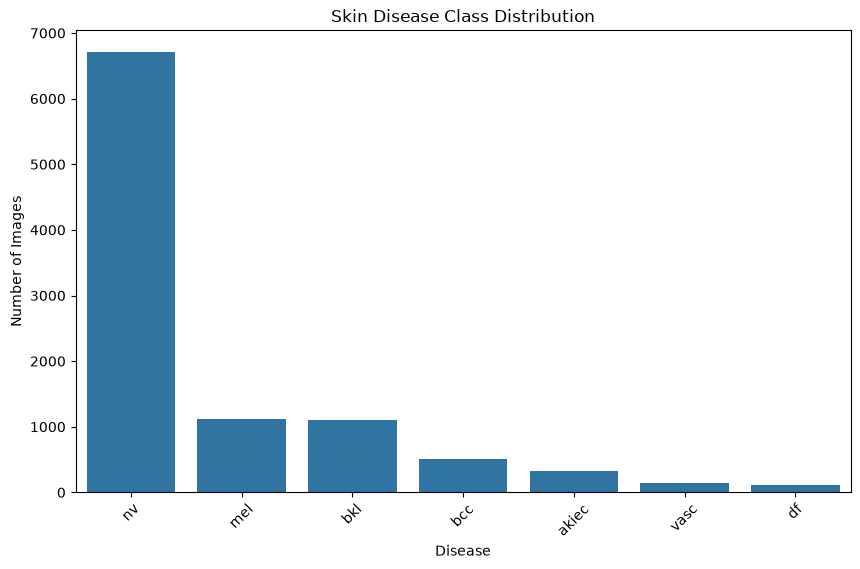

In [170]:
plt.figure(figsize=(10,6))
sns.countplot(data=data, x="dx", order=data["dx"].value_counts().index)
plt.title("Skin Disease Class Distribution")
plt.xlabel("Disease")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

In [171]:
# class percentage
class_percentage = (data["dx"].value_counts(normalize=True)*100)
print(class_percentage)

dx
nv       66.949576
mel      11.113330
bkl      10.973540
bcc       5.132302
akiec     3.265102
vasc      1.417873
df        1.148278
Name: proportion, dtype: float64


In [172]:
# class imbalance
print("Largest Class")
print(data["dx"].value_counts().idxmax())

print()

print("Smallest Class")
print(data["dx"].value_counts().idxmin())

Largest Class
nv

Smallest Class
df


In [173]:
import os
import glob

image_paths = {}
folders = ["dataset/HAM10000_images_part_1", "dataset/HAM10000_images_part_2"]
for folder in folders:
    for img_path in glob.glob(os.path.join(folder, "*.jpg")):
        image_id = os.path.splitext(os.path.basename(img_path))[0]
        image_paths[image_id] = img_path

print("Total images:", len(image_paths))

Total images: 10015


In [174]:
data["image_path"] = data["image_id"].map(image_paths)
print(data["image_path"].isnull().sum())

0


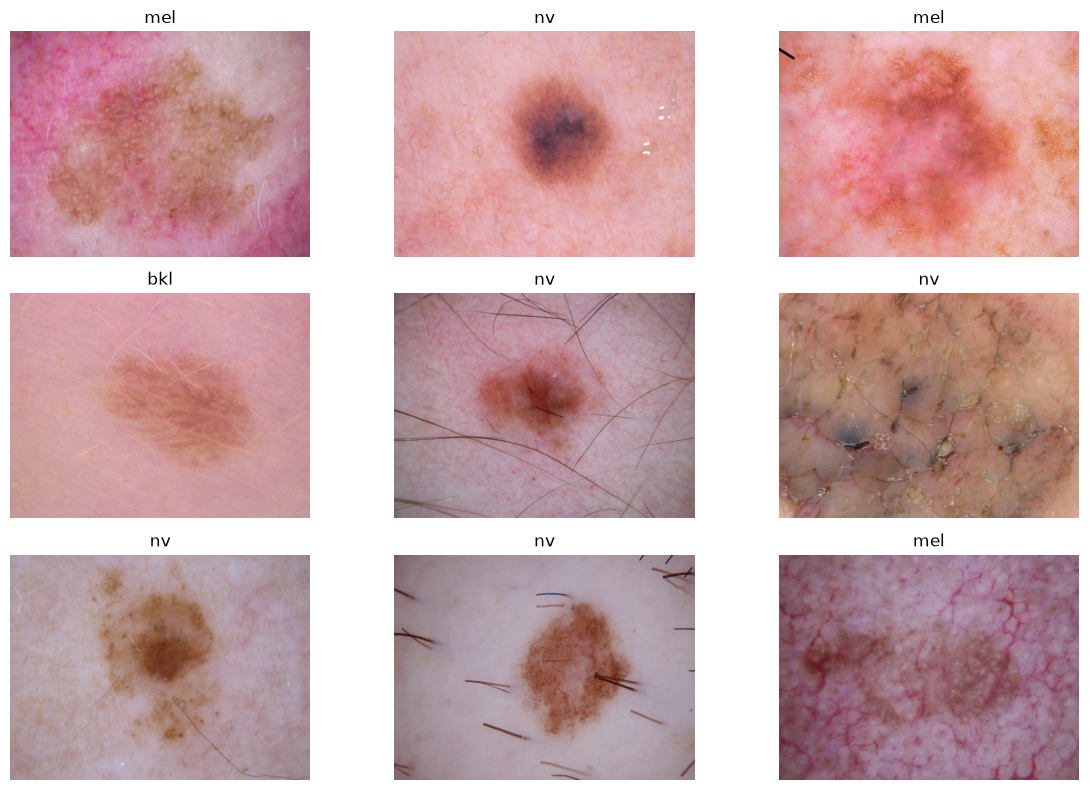

In [175]:
# sample images

from PIL import Image
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

sample = data.sample(9, random_state=42)

for i, (_, row) in enumerate(sample.iterrows()):
    img = Image.open(row["image_path"])

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(row["dx"])
    plt.axis("off")

plt.tight_layout()
plt.show()

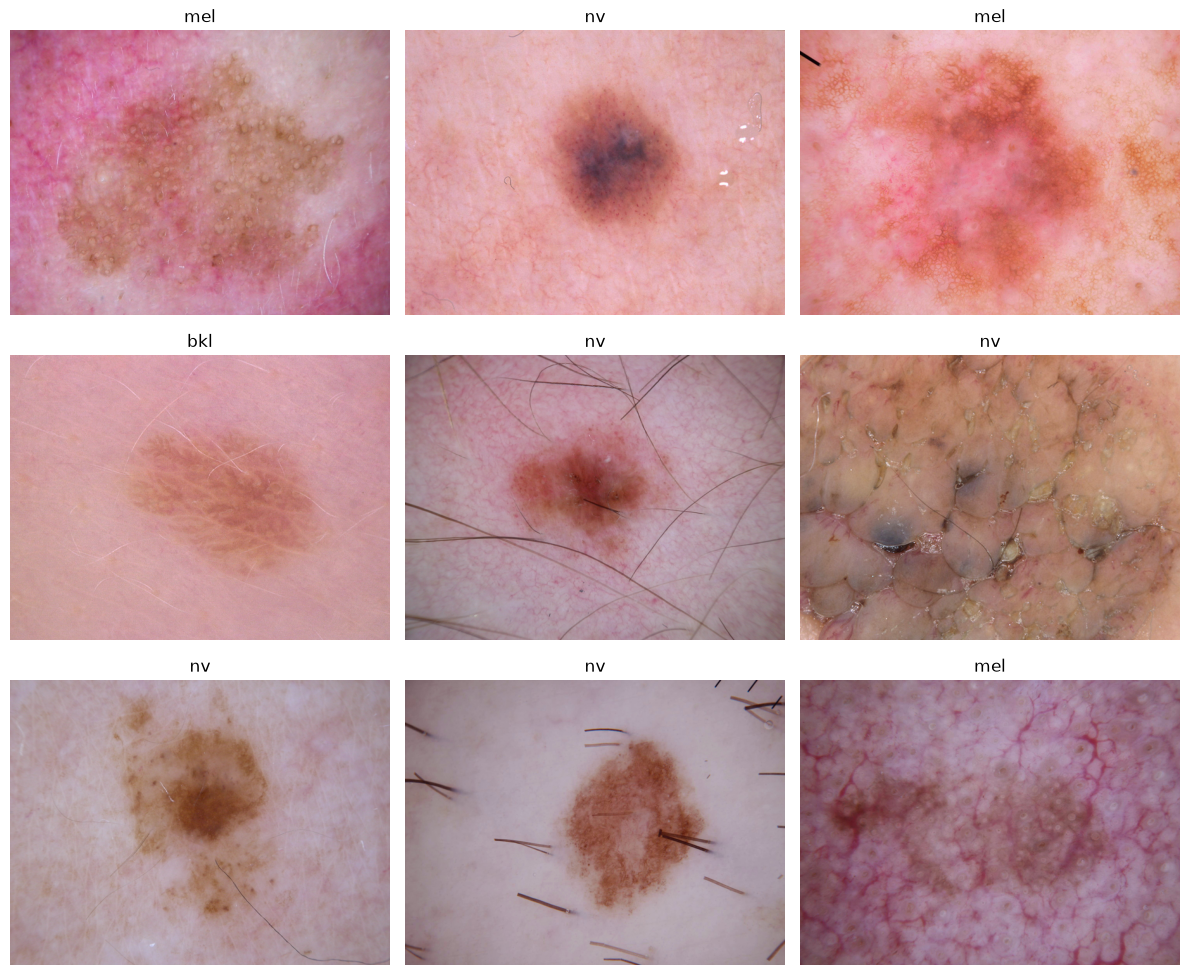

In [176]:
# 9 random sample images
from PIL import Image
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sample = data.sample(9, random_state=42)

for i, (_, row) in enumerate(sample.iterrows()):

    img = Image.open(row["image_path"])

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(row["dx"])
    plt.axis("off")

plt.tight_layout()
plt.show()

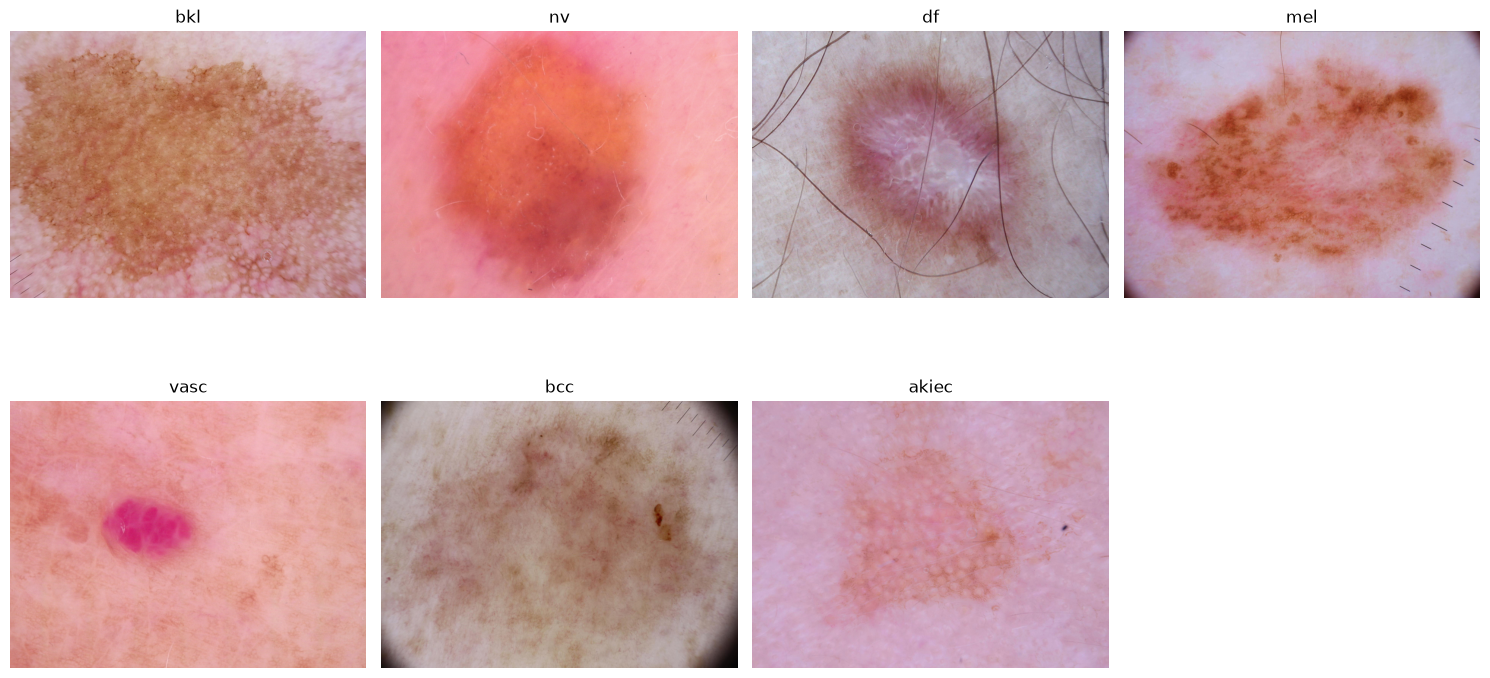

In [177]:
# One Image from Each Disease Class
classes = data["dx"].unique()

plt.figure(figsize=(15,8))

for i, disease in enumerate(classes):

    sample = data[data["dx"] == disease].sample(1, random_state=42)

    img = Image.open(sample.iloc[0]["image_path"])

    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title(disease)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [178]:
# image resolution
widths = []
heights = []
for path in data["image_path"]:

    img = Image.open(path)

    widths.append(img.size[0])
    heights.append(img.size[1])


In [179]:
print("Minimum Width :", min(widths))
print("Maximum Width :", max(widths))

print("Minimum Height :", min(heights))
print("Maximum Height :", max(heights))

Minimum Width : 600
Maximum Width : 600
Minimum Height : 450
Maximum Height : 450


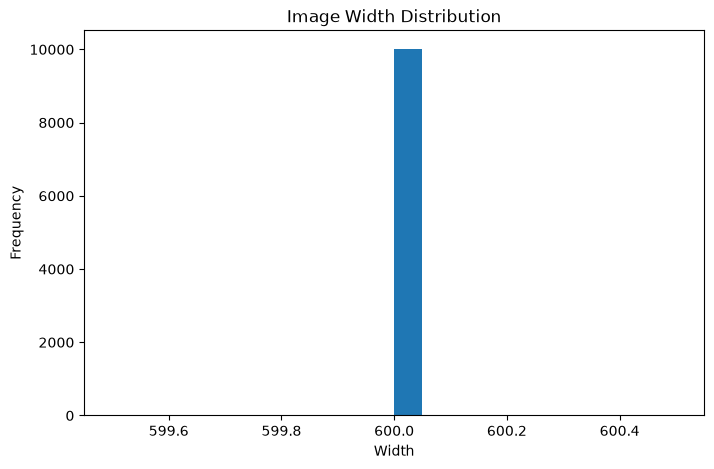

In [180]:
# width distribution
plt.figure(figsize=(8,5))
plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")
plt.show()

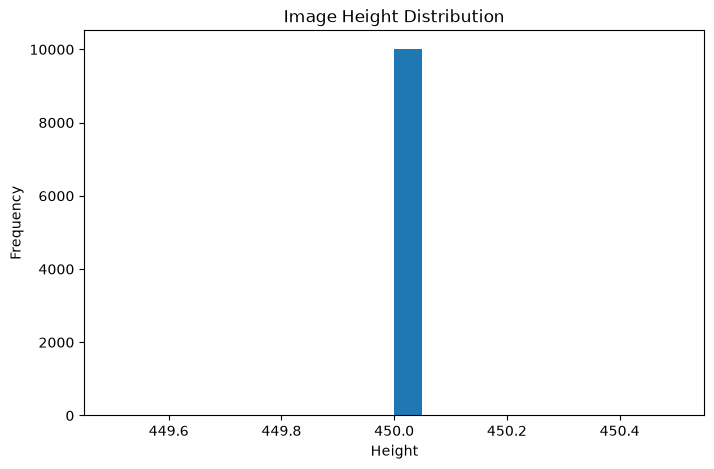

In [181]:
plt.figure(figsize=(8,5))
plt.hist(heights, bins=20)
plt.title("Image Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.show()

In [182]:
pip install cv2

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)
ERROR: No matching distribution found for cv2

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\SURYA\tfenv\Scripts\python.exe -m pip install --upgrade pip


In [183]:
import cv2
img = cv2.imread(data.iloc[0]["image_path"])
print(img.shape)

(450, 600, 3)


In [184]:
# tarin validation test-split
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    data,
    test_size=0.30,
    stratify=data["dx"],
    random_state=42
)

In [185]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["dx"],
    random_state=42
)

In [186]:
print("Training Dataset :", train_df.shape)
print("Validation Dataset :", val_df.shape)
print("Testing Dataset :", test_df.shape)

Training Dataset : (7010, 8)
Validation Dataset : (1502, 8)
Testing Dataset : (1503, 8)


In [187]:
print(train_df["dx"].value_counts())

print()

print(val_df["dx"].value_counts())

print()

print(test_df["dx"].value_counts())

dx
nv       4693
mel       779
bkl       769
bcc       360
akiec     229
vasc       99
df         81
Name: count, dtype: int64

dx
nv       1006
mel       167
bkl       165
bcc        77
akiec      49
vasc       21
df         17
Name: count, dtype: int64

dx
nv       1006
mel       167
bkl       165
bcc        77
akiec      49
vasc       22
df         17
Name: count, dtype: int64


In [188]:
train_df.to_csv("dataset/train_metadata.csv", index=False)
val_df.to_csv("dataset/val_metadata.csv", index=False)
test_df.to_csv("dataset/test_metadata.csv", index=False)

# Phase 2 – Data Preprocessing

In [189]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [190]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\SURYA\tfenv\Scripts\python.exe -m pip install --upgrade pip


In [191]:
import sys
print(sys.executable)

C:\Users\SURYA\tfenv\Scripts\python.exe


In [192]:
# resize image
IMAGE_SIZE = (224,224)
image = cv2.imread(data["image_path"].iloc[0])
resized_image = cv2.resize(image, IMAGE_SIZE)
print(resized_image.shape)

(224, 224, 3)


In [193]:
# nomalize pixel values
normalized_image = resized_image / 255.0
print(normalized_image.min())

print(normalized_image.max())


0.1843137254901961
0.996078431372549


In [194]:
# image agumentation


In [195]:
# rotation
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=20
)

In [196]:
# horizontal flip
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    horizontal_flip=True
)

In [197]:
# vertical flip
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    vertical_flip=True
)

In [198]:
# zoom
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    zoom_range=0.2
)

In [199]:
# brightness
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    brightness_range=[0.8,1.2]
)

In [200]:
# contrast
contrast = tf.keras.Sequential([
    tf.keras.layers.RandomContrast(0.2)
])

### purpose - improve robustness to diffrent camera settings

In [201]:
# random crop
crop = tf.keras.Sequential([
    tf.keras.layers.RandomCrop(200,200),
    tf.keras.layers.Resizing(224,224)
])

In [202]:
# handli class imbalance
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_df["dx"])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["dx"]
)

class_weights = dict(enumerate(weights))

print(class_weights)

{0: np.float64(4.37305053025577), 1: np.float64(2.7817460317460316), 2: np.float64(1.3022478172023035), 3: np.float64(12.36331569664903), 4: np.float64(1.285530900421786), 5: np.float64(0.21338772031292808), 6: np.float64(10.115440115440116)}


In [203]:
#create tensorflow data pipeline


In [204]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(7010, 8)
(1502, 8)
(1503, 8)


In [205]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [206]:
train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=20,

    width_shift_range=0.1,
    height_shift_range=0.1,

    horizontal_flip=True,
    vertical_flip=True,

    zoom_range=0.2,

    brightness_range=[0.8,1.2]
)

In [207]:
# Validation Generator
val_datagen = ImageDataGenerator(
    rescale=1./255
)

In [208]:
# Test Generator
test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [209]:
# create train  pipeline
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,

    x_col="image_path",

    y_col="dx",

    target_size=(224,224),

    batch_size=32,

    class_mode="categorical",

    shuffle=True
)

Found 7010 validated image filenames belonging to 7 classes.


In [210]:
# create validatation pipeline
val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,

    x_col="image_path",

    y_col="dx",

    target_size=(224,224),

    batch_size=32,

    class_mode="categorical",

    shuffle=False
)



Found 1502 validated image filenames belonging to 7 classes.


In [211]:
# create test pipeline
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,

    x_col="image_path",

    y_col="dx",

    target_size=(224,224),

    batch_size=32,

    class_mode="categorical",

    shuffle=False
)

Found 1503 validated image filenames belonging to 7 classes.


In [212]:
print(train_generator.class_indices)

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [213]:
# check image batch
images, labels = next(train_generator)

print(images.shape)
print(labels.shape)

(32, 224, 224, 3)
(32, 7)


In [214]:
print(train_generator.class_indices)

images, labels = next(train_generator)

print(images.shape)
print(labels.shape)

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
(32, 224, 224, 3)
(32, 7)


# Phase-3 Exploratory Analysis

In [215]:
# class distribution
counts = train_df["dx"].value_counts()
print(counts)

dx
nv       4693
mel       779
bkl       769
bcc       360
akiec     229
vasc       99
df         81
Name: count, dtype: int64


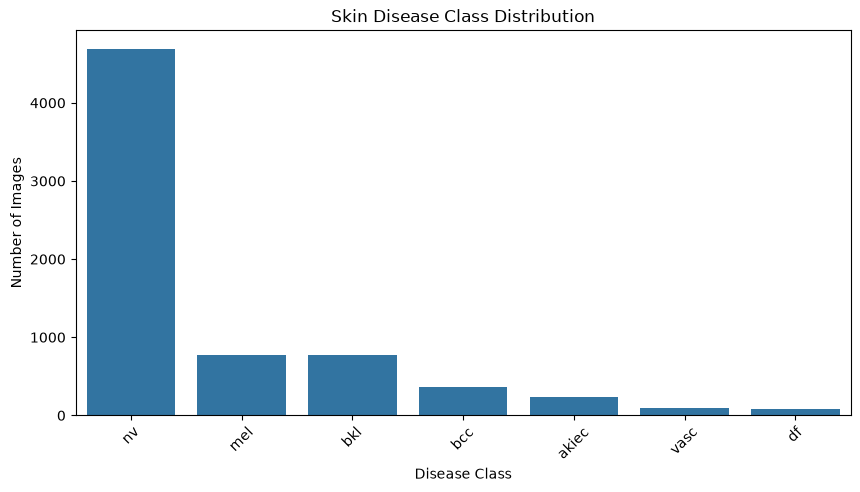

In [216]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=counts.index,
    y=counts.values
)

plt.title("Skin Disease Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.show()

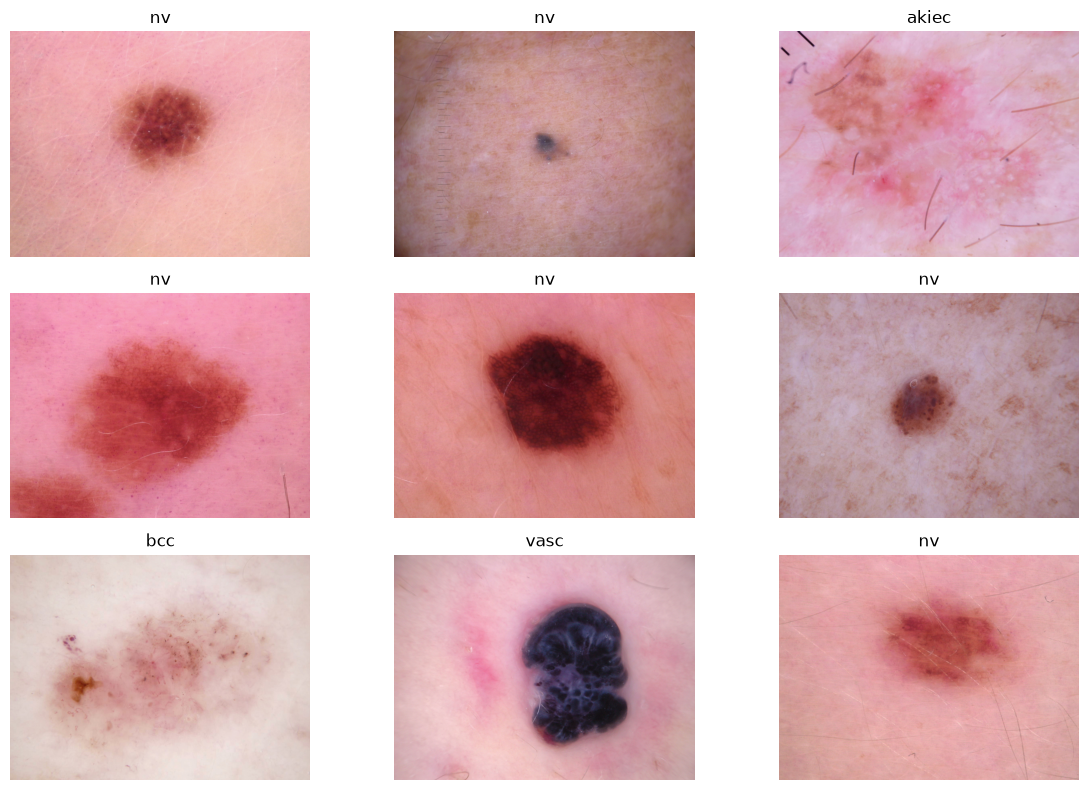

In [217]:
# display sample images
plt.figure(figsize=(12,8))

sample_data = train_df.sample(9)

for i, row in enumerate(sample_data.itertuples()):

    image = cv2.imread(row.image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(3,3,i+1)

    plt.imshow(image)

    plt.title(row.dx)

    plt.axis("off")


plt.tight_layout()
plt.show()

In [218]:
# image resolution analysis
import cv2

widths = []
heights = []


for path in train_df["image_path"].sample(500):

    img = cv2.imread(path)

    h,w,_ = img.shape

    heights.append(h)
    widths.append(w)


print("Average height:", np.mean(heights))
print("Average width:", np.mean(widths))

Average height: 450.0
Average width: 600.0


In [219]:
# pixel intensity analysis (understand image brightness)
image = cv2.imread(
    train_df["image_path"].iloc[0]
)

image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)


print("Minimum pixel:",
      image.min())

print("Maximum pixel:",
      image.max())

print("Mean pixel:",
      image.mean())

Minimum pixel: 17
Maximum pixel: 252
Mean pixel: 166.5175024691358


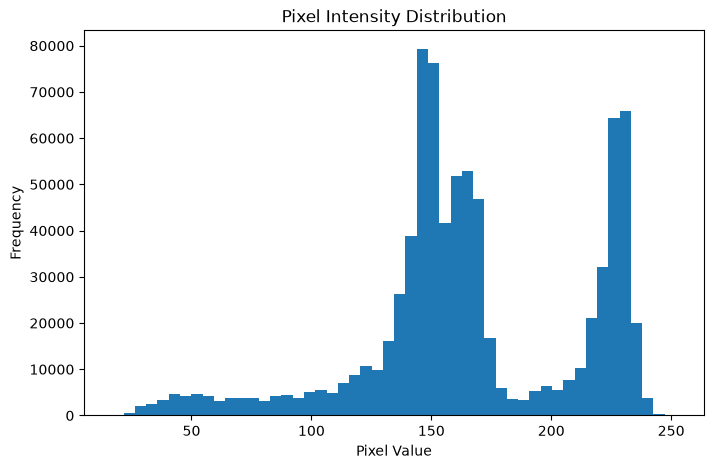

In [220]:
# pixel distribution plot
plt.figure(figsize=(8,5))

plt.hist(
    image.ravel(),
    bins=50
)

plt.title("Pixel Intensity Distribution")

plt.xlabel("Pixel Value")

plt.ylabel("Frequency")

plt.show()

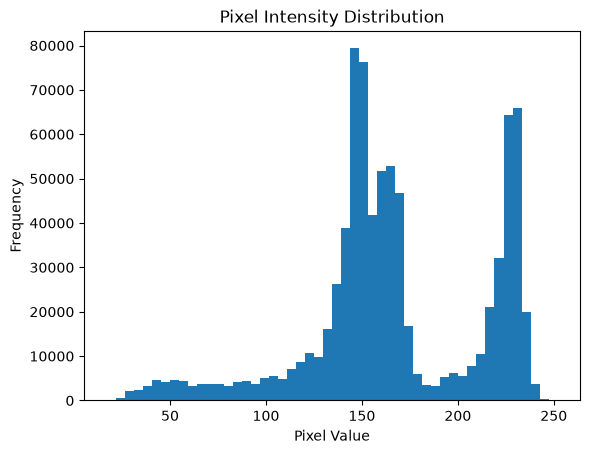

In [221]:
# plt.figure(figsize=(8,5))

plt.hist(
    image.ravel(),
    bins=50
)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.show()

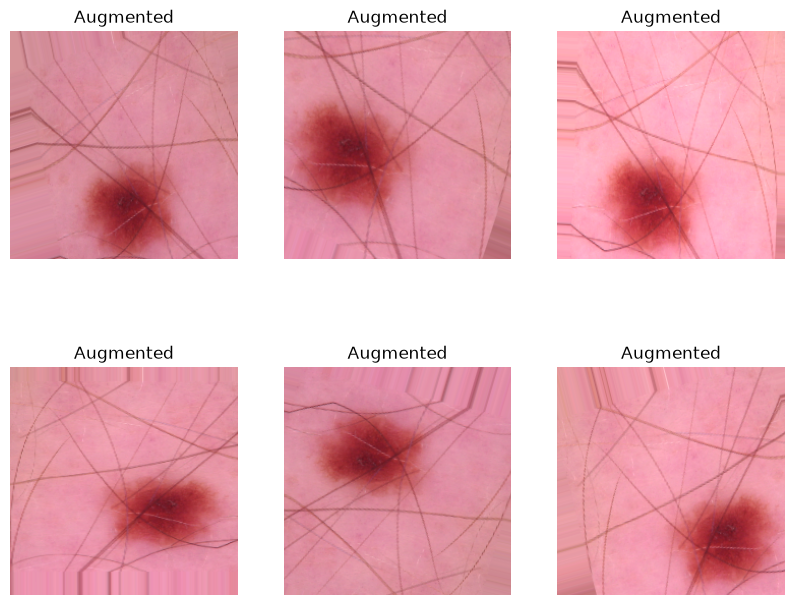

In [222]:
# augumentation comparison
from tensorflow.keras.preprocessing.image import img_to_array, load_img

sample_path = train_df["image_path"].iloc[0]

img = load_img(
    sample_path,
    target_size=(224,224)
)

img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)


augmented_images = train_datagen.flow(
    img_array,
    batch_size=1
)


plt.figure(figsize=(10,8))

for i in range(6):

    batch = next(augmented_images)

    plt.subplot(2,3,i+1)

    plt.imshow(batch[0])

    plt.axis("off")

    plt.title("Augmented")

plt.show()

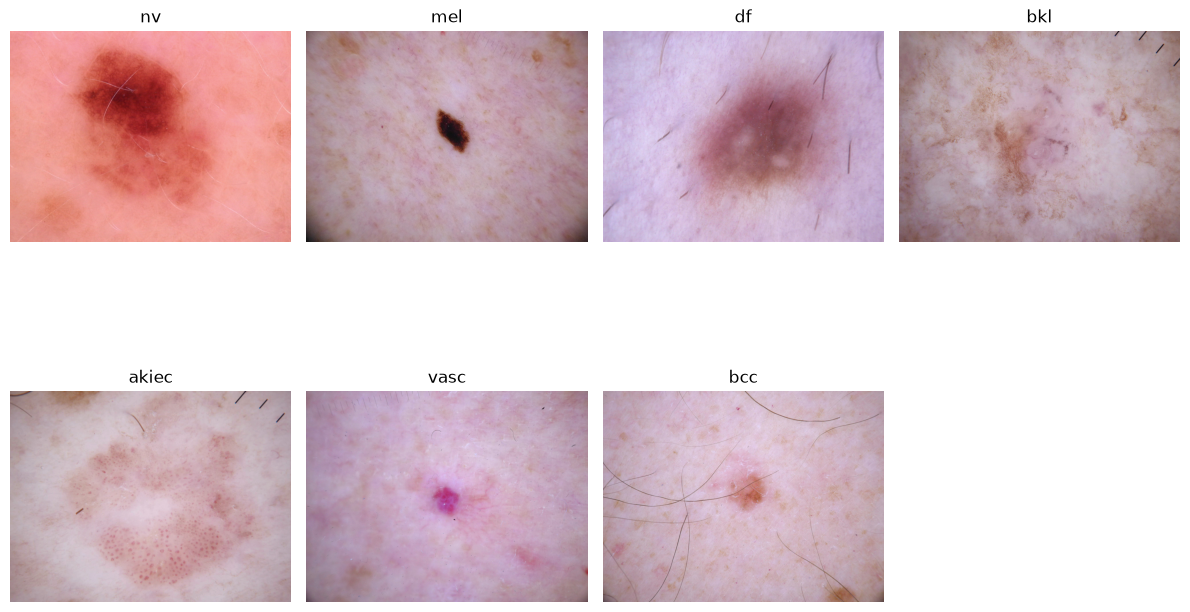

In [223]:
# class wise image charecteristics
plt.figure(figsize=(12,8))

classes = train_df["dx"].unique()

for i, cls in enumerate(classes):

    sample = train_df[train_df["dx"] == cls].sample(1)

    image = cv2.imread(sample["image_path"].values[0])

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(2,4,i+1)

    plt.imshow(image)

    plt.title(cls)

    plt.axis("off")


plt.tight_layout()
plt.show()

# phase-4 Model Development

In [76]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import Adam

In [77]:
# basic cnn model
model_cnn = Sequential()

# First Convolution Block
model_cnn.add(
    Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(224,224,3))
)

model_cnn.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Block
model_cnn.add(
    Conv2D(filters=64, kernel_size=(3,3), activation='relu')
)

model_cnn.add(MaxPooling2D(pool_size=(2,2)))


# Convert feature maps to vector
model_cnn.add(Flatten())


# Fully Connected Layer
model_cnn.add(Dense(128, activation='relu'))

# Output Layer
model_cnn.add(Dense(7, activation='softmax'))

C:\Users\SURYA\tfenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [78]:
model_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)       ┃ Output Shape ┃ Param # ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ conv2d (Conv2D)    │ (None, 222,  │     896 │
│                    │ 222, 32)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d      │ (None, 111,  │       0 │
│ (MaxPooling2D)     │ 111, 32)     │         │
├────────────────────┼──────────────┼─────────┤
│ conv2d_1 (Conv2D)  │ (None, 109,  │  18,496 │
│                    │ 109, 64)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_1    │ (None, 54,   │       0 │
│ (MaxPooling2D)     │ 54, 64)      │         │
├────────────────────┼──────────────┼─────────┤
│ flatten (Flatten)  │ (None,       │       0 │
│                    │ 186624)      │         │
├────────────────────┼──────────────┼─────────┤
│ dense (Dense)      │ (None, 128)  │ 23,888… │
├────────────────────┼──────────────┼─────────┤
│ dense_1 (Dense)    │ (None, 7)    │     903 │
└────────────────────┴──────────────┴─────────┘

 Total params: 23,908,295 (91.20 MB)

 Trainable params: 23,908,295 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compile the model
model_cnn.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [84]:
model_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)       ┃ Output Shape ┃ Param # ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ conv2d (Conv2D)    │ (None, 222,  │     896 │
│                    │ 222, 32)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d      │ (None, 111,  │       0 │
│ (MaxPooling2D)     │ 111, 32)     │         │
├────────────────────┼──────────────┼─────────┤
│ conv2d_1 (Conv2D)  │ (None, 109,  │  18,496 │
│                    │ 109, 64)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_1    │ (None, 54,   │       0 │
│ (MaxPooling2D)     │ 54, 64)      │         │
├────────────────────┼──────────────┼─────────┤
│ flatten (Flatten)  │ (None,       │       0 │
│                    │ 186624)      │         │
├────────────────────┼──────────────┼─────────┤
│ dense (Dense)      │ (None, 128)  │ 23,888… │
├────────────────────┼──────────────┼─────────┤
│ dense_1 (Dense)    │ (None, 7)    │     903 │
└────────────────────┴──────────────┴─────────┘

 Total params: 71,724,887 (273.61 MB)

 Trainable params: 23,908,295 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 47,816,592 (182.41 MB)

In [81]:
model_cnn.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [82]:
model_cnn.optimizer

In [83]:
# train basic cnn
history_cnn = model_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 448s 2s/step - accuracy: 0.3556 - loss: 1.9520 - val_accuracy: 0.4720 - val_loss: 1.5030
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 592s 2s/step - accuracy: 0.4719 - loss: 1.7602 - val_accuracy: 0.5526 - val_loss: 1.3092
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 707s 3s/step - accuracy: 0.4633 - loss: 1.5918 - val_accuracy: 0.4614 - val_loss: 1.3643
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 783s 3s/step - accuracy: 0.4862 - loss: 1.4632 - val_accuracy: 0.4767 - val_loss: 1.3133
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 701s 3s/step - accuracy: 0.4886 - loss: 1.4379 - val_accuracy: 0.5246 - val_loss: 1.2501


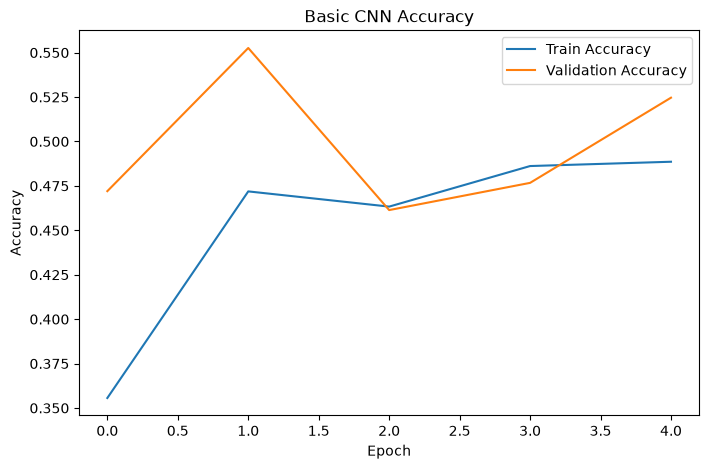

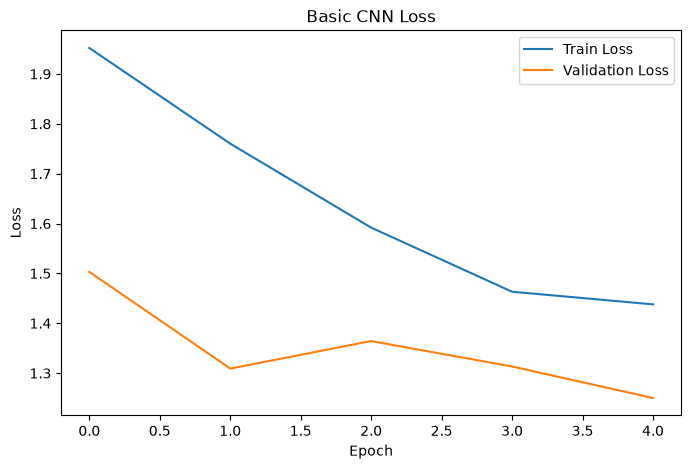

In [85]:
# plotty accourance nd curve
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history_cnn.history["accuracy"], label="Train Accuracy")
plt.plot(history_cnn.history["val_accuracy"], label="Validation Accuracy")
plt.title("Basic CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history_cnn.history["loss"], label="Train Loss")
plt.plot(history_cnn.history["val_loss"], label="Validation Loss")
plt.title("Basic CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [86]:
#test set
test_loss, test_accuracy = model_cnn.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.4930 - loss: 1.2747
Test Loss: 1.274704933166504
Test Accuracy: 0.49301397800445557


In [87]:
import os
os.makedirs("models", exist_ok=True)
model_cnn.save("models/basic_cnn.keras")

In [88]:
# DEEP CNN

In [89]:
deep_cnn = Sequential()

# Block 1
deep_cnn.add(Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)))
deep_cnn.add(MaxPooling2D((2,2)))

# Block 2
deep_cnn.add(Conv2D(64, (3,3), activation="relu"))
deep_cnn.add(MaxPooling2D((2,2)))

# Block 3
deep_cnn.add(Conv2D(128, (3,3), activation="relu"))
deep_cnn.add(MaxPooling2D((2,2)))

# Block 4
deep_cnn.add(Conv2D(256, (3,3), activation="relu"))
deep_cnn.add(MaxPooling2D((2,2)))

# Fully Connected Layer
deep_cnn.add(Flatten())
deep_cnn.add(Dense(256, activation="relu"))

# Output Layer (7 diseases)
deep_cnn.add(Dense(7, activation="softmax"))

deep_cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)       ┃ Output Shape ┃ Param # ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ conv2d_2 (Conv2D)  │ (None, 222,  │     896 │
│                    │ 222, 32)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_2    │ (None, 111,  │       0 │
│ (MaxPooling2D)     │ 111, 32)     │         │
├────────────────────┼──────────────┼─────────┤
│ conv2d_3 (Conv2D)  │ (None, 109,  │  18,496 │
│                    │ 109, 64)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_3    │ (None, 54,   │       0 │
│ (MaxPooling2D)     │ 54, 64)      │         │
├────────────────────┼──────────────┼─────────┤
│ conv2d_4 (Conv2D)  │ (None, 52,   │  73,856 │
│                    │ 52, 128)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_4    │ (None, 26,   │       0 │
│ (MaxPooling2D)     │ 26, 128)     │         │
├────────────────────┼──────────────┼─────────┤
│ conv2d_5 (Conv2D)  │ (None, 24,   │ 295,168 │
│                    │ 24, 256)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_5    │ (None, 12,   │       0 │
│ (MaxPooling2D)     │ 12, 256)     │         │
├────────────────────┼──────────────┼─────────┤
│ flatten_1          │ (None,       │       0 │
│ (Flatten)          │ 36864)       │         │
├────────────────────┼──────────────┼─────────┤
│ dense_2 (Dense)    │ (None, 256)  │ 9,437,… │
├────────────────────┼──────────────┼─────────┤
│ dense_3 (Dense)    │ (None, 7)    │   1,799 │
└────────────────────┴──────────────┴─────────┘

 Total params: 9,827,655 (37.49 MB)

 Trainable params: 9,827,655 (37.49 MB)

 Non-trainable params: 0 (0.00 B)

In [90]:
# compile the model
deep_cnn.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [91]:
history_deep = deep_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 943s 4s/step - accuracy: 0.4124 - loss: 1.8635 - val_accuracy: 0.4667 - val_loss: 1.4129
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 879s 4s/step - accuracy: 0.4285 - loss: 1.6785 - val_accuracy: 0.4607 - val_loss: 1.3777
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 920s 4s/step - accuracy: 0.4591 - loss: 1.4690 - val_accuracy: 0.5166 - val_loss: 1.1733
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 768s 3s/step - accuracy: 0.4559 - loss: 1.4017 - val_accuracy: 0.5752 - val_loss: 1.0789
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 543s 2s/step - accuracy: 0.4797 - loss: 1.3525 - val_accuracy: 0.4874 - val_loss: 1.2767


In [92]:
test_loss, test_accuracy = deep_cnn.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 32s 677ms/step - accuracy: 0.4664 - loss: 1.3052
Test Loss: 1.3052268028259277
Test Accuracy: 0.46640053391456604


In [93]:
deep_cnn.save("models/deep_cnn.keras")

In [349]:
comparison = []
comparison.append({
    "Model": "Basic CNN",
    "Train Accuracy": 48.86,
    "Validation Accuracy": 52.46,
    "Test Accuracy": 49.30,
    "Train Loss": 1.4379,
    "Validation Loss": 1.2501,
    "Test Loss": 1.2747
})

In [350]:
comparison.append({
    "Model": "Deep CNN",
    "Train Accuracy": 47.97,
    "Validation Accuracy": 48.74,
    "Test Accuracy": 46.64,
    "Train Loss": 1.3525,
    "Validation Loss": 1.2767,
    "Test Loss": 1.3052
})

In [98]:
comparison_datas = pd.DataFrame(comparison_results)
comparison_datas

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,Basic CNN,48.86,52.46,49.30,1.4379,1.2501,1.2747
1,Deep CNN,47.97,48.74,46.64,1.3525,1.2767,1.3052


In [99]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import BatchNormalization

In [101]:
batch_normalization = Sequential(name="CNN_BatchNormalization")

# Block 1
batch_normalization.add(Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)))
batch_normalization.add(BatchNormalization())
batch_normalization.add(MaxPooling2D((2,2)))

# Block 2
batch_normalization.add(Conv2D(64, (3,3), activation="relu"))
batch_normalization.add(BatchNormalization())
batch_normalization.add(MaxPooling2D((2,2)))

# Block 3
batch_normalization.add(Conv2D(128, (3,3), activation="relu"))
batch_normalization.add(BatchNormalization())
batch_normalization.add(MaxPooling2D((2,2)))

# Block 4
batch_normalization.add(Conv2D(256, (3,3), activation="relu"))
batch_normalization.add(BatchNormalization())
batch_normalization.add(MaxPooling2D((2,2)))

# Fully Connected Layer
batch_normalization.add(Flatten())
batch_normalization.add(Dense(256, activation="relu"))

# Output Layer
batch_normalization.add(Dense(7, activation="softmax"))

batch_normalization.summary()

Model: "CNN_BatchNormalization"

┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)       ┃ Output Shape ┃ Param # ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ conv2d_10 (Conv2D) │ (None, 222,  │     896 │
│                    │ 222, 32)     │         │
├────────────────────┼──────────────┼─────────┤
│ batch_normalizati… │ (None, 222,  │     128 │
│ (BatchNormalizati… │ 222, 32)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_10   │ (None, 111,  │       0 │
│ (MaxPooling2D)     │ 111, 32)     │         │
├────────────────────┼──────────────┼─────────┤
│ conv2d_11 (Conv2D) │ (None, 109,  │  18,496 │
│                    │ 109, 64)     │         │
├────────────────────┼──────────────┼─────────┤
│ batch_normalizati… │ (None, 109,  │     256 │
│ (BatchNormalizati… │ 109, 64)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_11   │ (None, 54,   │       0 │
│ (MaxPooling2D)     │ 54, 64)      │         │
├────────────────────┼──────────────┼─────────┤
│ conv2d_12 (Conv2D) │ (None, 52,   │  73,856 │
│                    │ 52, 128)     │         │
├────────────────────┼──────────────┼─────────┤
│ batch_normalizati… │ (None, 52,   │     512 │
│ (BatchNormalizati… │ 52, 128)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_12   │ (None, 26,   │       0 │
│ (MaxPooling2D)     │ 26, 128)     │         │
├────────────────────┼──────────────┼─────────┤
│ conv2d_13 (Conv2D) │ (None, 24,   │ 295,168 │
│                    │ 24, 256)     │         │
├────────────────────┼──────────────┼─────────┤
│ batch_normalizati… │ (None, 24,   │   1,024 │
│ (BatchNormalizati… │ 24, 256)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_13   │ (None, 12,   │       0 │
│ (MaxPooling2D)     │ 12, 256)     │         │
├────────────────────┼──────────────┼─────────┤
│ flatten_3          │ (None,       │       0 │
│ (Flatten)          │ 36864)       │         │
├────────────────────┼──────────────┼─────────┤
│ dense_6 (Dense)    │ (None, 256)  │ 9,437,… │
├────────────────────┼──────────────┼─────────┤
│ dense_7 (Dense)    │ (None, 7)    │   1,799 │
└────────────────────┴──────────────┴─────────┘

 Total params: 9,829,575 (37.50 MB)

 Trainable params: 9,828,615 (37.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [102]:
batch_normalization.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [103]:
history_batch_normalization = batch_normalization.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 765s 3s/step - accuracy: 0.4180 - loss: 2.1976 - val_accuracy: 0.0140 - val_loss: 7.8258
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 765s 3s/step - accuracy: 0.4951 - loss: 1.4516 - val_accuracy: 0.6039 - val_loss: 1.5762
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 760s 3s/step - accuracy: 0.5136 - loss: 1.3018 - val_accuracy: 0.5679 - val_loss: 1.2165
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 841s 4s/step - accuracy: 0.5161 - loss: 1.3110 - val_accuracy: 0.4854 - val_loss: 1.4365
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 1329s 6s/step - accuracy: 0.5355 - loss: 1.2778 - val_accuracy: 0.4820 - val_loss: 1.4709


In [106]:
# Validation Accuracy
test_loss, test_accuracy = batch_normalization.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.4697 - loss: 1.5244
Test Loss: 1.5244275331497192
Test Accuracy: 0.46972721815109253


In [107]:
batch_normalization.save("models/batch_normalization.keras")

print("CNN + Batch Normalization model saved successfully!")

CNN + Batch Normalization model saved successfully!


In [351]:
comparison.append({
    "Model": "CNN + Batch Normalization",
    "Train Accuracy": 53.55,
    "Validation Accuracy": 48.20,
    "Test Accuracy": 46.97,
    "Train Loss": 1.2778,
    "Validation Loss": 1.4709,
    "Test Loss": 1.5244
})

In [121]:
comparison_datas = pd.DataFrame(comparison)
comparison_datas

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,Basic CNN,48.86,52.46,49.30,1.4379,1.2501,1.2747
1,Deep CNN,47.97,48.74,46.64,1.3525,1.2767,1.3052
2,CNN + Batch Normalization,53.55,48.20,46.97,1.2778,1.4709,1.5244
3,CNN + Dropout,43.20,55.93,56.69,1.7103,1.3193,1.3342


In [110]:
# CNN DROOUT
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [111]:
cnn_dropout = Sequential(name="CNN_Dropout")

# Block 1
cnn_dropout.add(Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)))
cnn_dropout.add(MaxPooling2D((2,2)))
cnn_dropout.add(Dropout(0.25))

# Block 2
cnn_dropout.add(Conv2D(64, (3,3), activation="relu"))
cnn_dropout.add(MaxPooling2D((2,2)))
cnn_dropout.add(Dropout(0.25))

# Block 3
cnn_dropout.add(Conv2D(128, (3,3), activation="relu"))
cnn_dropout.add(MaxPooling2D((2,2)))
cnn_dropout.add(Dropout(0.25))

# Block 4
cnn_dropout.add(Conv2D(256, (3,3), activation="relu"))
cnn_dropout.add(MaxPooling2D((2,2)))
cnn_dropout.add(Dropout(0.25))

# Fully Connected Layer
cnn_dropout.add(Flatten())
cnn_dropout.add(Dense(256, activation="relu"))
cnn_dropout.add(Dropout(0.5))

# Output Layer
cnn_dropout.add(Dense(7, activation="softmax"))

cnn_dropout.summary()

Model: "CNN_Dropout"

┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)       ┃ Output Shape ┃ Param # ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ conv2d_15 (Conv2D) │ (None, 222,  │     896 │
│                    │ 222, 32)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_15   │ (None, 111,  │       0 │
│ (MaxPooling2D)     │ 111, 32)     │         │
├────────────────────┼──────────────┼─────────┤
│ dropout (Dropout)  │ (None, 111,  │       0 │
│                    │ 111, 32)     │         │
├────────────────────┼──────────────┼─────────┤
│ conv2d_16 (Conv2D) │ (None, 109,  │  18,496 │
│                    │ 109, 64)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_16   │ (None, 54,   │       0 │
│ (MaxPooling2D)     │ 54, 64)      │         │
├────────────────────┼──────────────┼─────────┤
│ dropout_1          │ (None, 54,   │       0 │
│ (Dropout)          │ 54, 64)      │         │
├────────────────────┼──────────────┼─────────┤
│ conv2d_17 (Conv2D) │ (None, 52,   │  73,856 │
│                    │ 52, 128)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_17   │ (None, 26,   │       0 │
│ (MaxPooling2D)     │ 26, 128)     │         │
├────────────────────┼──────────────┼─────────┤
│ dropout_2          │ (None, 26,   │       0 │
│ (Dropout)          │ 26, 128)     │         │
├────────────────────┼──────────────┼─────────┤
│ conv2d_18 (Conv2D) │ (None, 24,   │ 295,168 │
│                    │ 24, 256)     │         │
├────────────────────┼──────────────┼─────────┤
│ max_pooling2d_18   │ (None, 12,   │       0 │
│ (MaxPooling2D)     │ 12, 256)     │         │
├────────────────────┼──────────────┼─────────┤
│ dropout_3          │ (None, 12,   │       0 │
│ (Dropout)          │ 12, 256)     │         │
├────────────────────┼──────────────┼─────────┤
│ flatten_4          │ (None,       │       0 │
│ (Flatten)          │ 36864)       │         │
├────────────────────┼──────────────┼─────────┤
│ dense_8 (Dense)    │ (None, 256)  │ 9,437,… │
├────────────────────┼──────────────┼─────────┤
│ dropout_4          │ (None, 256)  │       0 │
│ (Dropout)          │              │         │
├────────────────────┼──────────────┼─────────┤
│ dense_9 (Dense)    │ (None, 7)    │   1,799 │
└────────────────────┴──────────────┴─────────┘

 Total params: 9,827,655 (37.49 MB)

 Trainable params: 9,827,655 (37.49 MB)

 Non-trainable params: 0 (0.00 B)

In [112]:
cnn_dropout.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [113]:
history_dropout = cnn_dropout.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 839s 4s/step - accuracy: 0.3582 - loss: 1.9528 - val_accuracy: 0.4634 - val_loss: 1.6980
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 487s 2s/step - accuracy: 0.3999 - loss: 1.8411 - val_accuracy: 0.4854 - val_loss: 1.4673
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 482s 2s/step - accuracy: 0.3987 - loss: 1.8197 - val_accuracy: 0.4607 - val_loss: 1.5753
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 483s 2s/step - accuracy: 0.4272 - loss: 1.7709 - val_accuracy: 0.5386 - val_loss: 1.3380
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 478s 2s/step - accuracy: 0.4320 - loss: 1.7103 - val_accuracy: 0.5593 - val_loss: 1.3193


In [252]:
test_loss, test_accuracy = cnn_dropout.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 31s 648ms/step - accuracy: 0.5669 - loss: 1.3342
Test Loss: 1.3342143297195435
Test Accuracy: 0.5668662786483765


In [253]:
cnn_dropout.save("models/CNN_Dropout.keras")

print("dropout model saved successfully!")

dropout model saved successfully!


In [352]:
comparison.append({
    "Model": "CNN + Dropout",
    "Train Accuracy": 43.20,
    "Validation Accuracy": 55.93,
    "Test Accuracy": 56.69,
    "Train Loss": 1.7103,
    "Validation Loss": 1.3193,
    "Test Loss": 1.3342
})

In [123]:
comparison_datas = pd.DataFrame(comparison)
comparison_datas

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,Basic CNN,48.86,52.46,49.30,1.4379,1.2501,1.2747
1,Deep CNN,47.97,48.74,46.64,1.3525,1.2767,1.3052
2,CNN + Batch Normalization,53.55,48.20,46.97,1.2778,1.4709,1.5244
3,CNN + Dropout,43.20,55.93,56.69,1.7103,1.3193,1.3342


In [124]:
#MobileNetV2

In [125]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [126]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [127]:
base_model.trainable = False

In [130]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)

x = Dropout(0.5)(x)

output = Dense(7, activation="softmax")(x)

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=output,
    name="MobileNetV2"
)

In [131]:
mobilenet_model.summary()

Model: "MobileNetV2"

┏━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━┓
┃ Layer       ┃ Output    ┃ Par… ┃ Connected  ┃
┃ (type)      ┃ Shape     ┃    # ┃ to         ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━┩
│ input_laye… │ (None,    │    0 │ -          │
│ (InputLaye… │ 224, 224, │      │            │
│             │ 3)        │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ Conv1       │ (None,    │  864 │ input_lay… │
│ (Conv2D)    │ 112, 112, │      │            │
│             │ 32)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ bn_Conv1    │ (None,    │  128 │ Conv1[0][… │
│ (BatchNorm… │ 112, 112, │      │            │
│             │ 32)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ Conv1_relu  │ (None,    │    0 │ bn_Conv1[… │
│ (ReLU)      │ 112, 112, │      │            │
│             │ 32)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ expanded_c… │ (None,    │  288 │ Conv1_rel… │
│ (Depthwise… │ 112, 112, │      │            │
│             │ 32)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ expanded_c… │ (None,    │  128 │ expanded_… │
│ (BatchNorm… │ 112, 112, │      │            │
│             │ 32)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ expanded_c… │ (None,    │    0 │ expanded_… │
│ (ReLU)      │ 112, 112, │      │            │
│             │ 32)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ expanded_c… │ (None,    │  512 │ expanded_… │
│ (Conv2D)    │ 112, 112, │      │            │
│             │ 16)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ expanded_c… │ (None,    │   64 │ expanded_… │
│ (BatchNorm… │ 112, 112, │      │            │
│             │ 16)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block_1_ex… │ (None,    │ 1,5… │ expanded_… │
│ (Conv2D)    │ 112, 112, │      │            │
│             │ 96)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block_1_ex… │ (None,    │  384 │ block_1_e… │
│ (BatchNorm… │ 112, 112, │      │            │
│             │ 96)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block_1_ex… │ (None,    │    0 │ block_1_e… │
│ (ReLU)      │ 112, 112, │      │            │
│             │ 96)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block_1_pad │ (None,    │    0 │ block_1_e… │
│ (ZeroPaddi… │ 113, 113, │      │            │
│             │ 96)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block_1_de… │ (None,    │  864 │ block_1_p… │
│ (Depthwise… │ 56, 56,   │      │            │
│             │ 96)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block_1_de… │ (None,    │  384 │ block_1_d… │
│ (BatchNorm… │ 56, 56,   │      │            │
│             │ 96)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block_1_de… │ (None,    │    0 │ block_1_d… │
│ (ReLU)      │ 56, 56,   │      │            │
│             │ 96)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block_1_pr… │ (None,    │ 2,3… │ block_1_d… │
│ (Conv2D)    │ 56, 56,   │      │            │
│             │ 24)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block_1_pr… │ (None,    │   96 │ block_1_p… │
│ (BatchNorm… │ 56, 56,   │      │            │
│             │ 24)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block_2_ex… │ (None,    │ 3,4… │ block_1_p… │
│ (Conv2D)    │ 56, 56,   │      │            │
│             │ 144)      │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block_2_ex… │ (None,    │  576 │ block_2_e… │
│ (BatchNorm… │ 56, 56,   │      │            │
│             │ 144)      │      │            │
├─────────────┼─

 Total params: 2,587,719 (9.87 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [132]:
mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [133]:
history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 422s 2s/step - accuracy: 0.2715 - loss: 1.9862 - val_accuracy: 0.5373 - val_loss: 1.4308
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 445s 2s/step - accuracy: 0.3877 - loss: 1.6292 - val_accuracy: 0.5546 - val_loss: 1.3646
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 382s 2s/step - accuracy: 0.4551 - loss: 1.4904 - val_accuracy: 0.5719 - val_loss: 1.2854
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 591s 3s/step - accuracy: 0.4531 - loss: 1.4369 - val_accuracy: 0.5866 - val_loss: 1.1960
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 1203s 5s/step - accuracy: 0.4835 - loss: 1.3777 - val_accuracy: 0.5726 - val_loss: 1.2121


In [134]:
test_loss, test_accuracy = mobilenet_model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.5469 - loss: 1.2640
Test Loss: 1.2640066146850586
Test Accuracy: 0.5469061732292175


In [314]:
# comparison.append({
#     "Model": "MobileNetV2",
#     "Train Accuracy": 48.35,
#     "Validation Accuracy": 57.26,
#     "Test Accuracy": 54.69,
#     "Train Loss": 1.3777,
#     "Validation Loss": 1.2121,
#     "Test Loss": 1.2640
# })

In [353]:
comparison_datas = pd.DataFrame(comparison)
comparison_datas

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,Basic CNN,48.86,52.46,49.30,1.4379,1.2501,1.2747
1,Deep CNN,47.97,48.74,46.64,1.3525,1.2767,1.3052
2,CNN + Batch Normalization,53.55,48.20,46.97,1.2778,1.4709,1.5244
3,CNN + Dropout,43.20,55.93,56.69,1.7103,1.3193,1.3342


In [137]:
mobilenet_model.save("models/mobilenetv2.keras")

print("MobileNetV2 model saved successfully!")

MobileNetV2 model saved successfully!


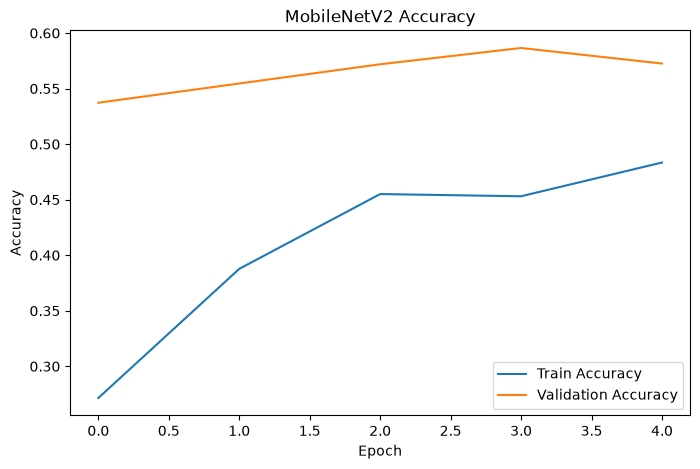

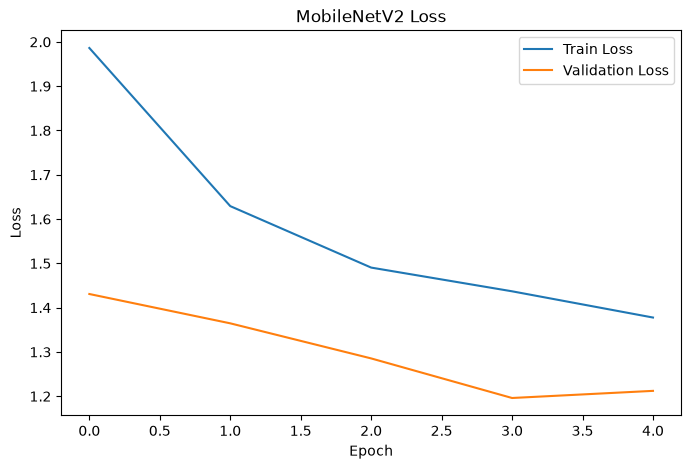

In [145]:
#
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history_mobilenet.history["accuracy"], label="Train Accuracy")
plt.plot(history_mobilenet.history["val_accuracy"], label="Validation Accuracy")
plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history_mobilenet.history["loss"], label="Train Loss")
plt.plot(history_mobilenet.history["val_loss"], label="Validation Loss")
plt.title("MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input


In [140]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [141]:
base_model.trainable = False

In [249]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)

x = Dropout(0.5)(x)

output = Dense(7, activation="softmax")(x)

efficientnet_model = Model(
    inputs=base_model.input,
    outputs=output,
    name="EfficientNetB0"
)

efficientnet_model.summary()

Model: "EfficientNetB0"

┏━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━┓
┃ Layer       ┃ Output    ┃ Par… ┃ Connected  ┃
┃ (type)      ┃ Shape     ┃    # ┃ to         ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━┩
│ input_laye… │ (None,    │    0 │ -          │
│ (InputLaye… │ 224, 224, │      │            │
│             │ 3)        │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ rescaling_4 │ (None,    │    0 │ input_lay… │
│ (Rescaling) │ 224, 224, │      │            │
│             │ 3)        │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ normalizat… │ (None,    │    7 │ rescaling… │
│ (Normaliza… │ 224, 224, │      │            │
│             │ 3)        │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ rescaling_5 │ (None,    │    0 │ normaliza… │
│ (Rescaling) │ 224, 224, │      │            │
│             │ 3)        │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ stem_conv_… │ (None,    │    0 │ rescaling… │
│ (ZeroPaddi… │ 225, 225, │      │            │
│             │ 3)        │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ stem_conv   │ (None,    │  864 │ stem_conv… │
│ (Conv2D)    │ 112, 112, │      │            │
│             │ 32)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ stem_bn     │ (None,    │  128 │ stem_conv… │
│ (BatchNorm… │ 112, 112, │      │            │
│             │ 32)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ stem_activ… │ (None,    │    0 │ stem_bn[0… │
│ (Activatio… │ 112, 112, │      │            │
│             │ 32)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block1a_dw… │ (None,    │  288 │ stem_acti… │
│ (Depthwise… │ 112, 112, │      │            │
│             │ 32)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block1a_bn  │ (None,    │  128 │ block1a_d… │
│ (BatchNorm… │ 112, 112, │      │            │
│             │ 32)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block1a_ac… │ (None,    │    0 │ block1a_b… │
│ (Activatio… │ 112, 112, │      │            │
│             │ 32)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block1a_se… │ (None,    │    0 │ block1a_a… │
│ (GlobalAve… │ 32)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block1a_se… │ (None, 1, │    0 │ block1a_s… │
│ (Reshape)   │ 1, 32)    │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block1a_se… │ (None, 1, │  264 │ block1a_s… │
│ (Conv2D)    │ 1, 8)     │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block1a_se… │ (None, 1, │  288 │ block1a_s… │
│ (Conv2D)    │ 1, 32)    │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block1a_se… │ (None,    │    0 │ block1a_a… │
│ (Multiply)  │ 112, 112, │      │ block1a_s… │
│             │ 32)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block1a_pr… │ (None,    │  512 │ block1a_s… │
│ (Conv2D)    │ 112, 112, │      │            │
│             │ 16)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block1a_pr… │ (None,    │   64 │ block1a_p… │
│ (BatchNorm… │ 112, 112, │      │            │
│             │ 16)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block2a_ex… │ (None,    │ 1,5… │ block1a_p… │
│ (Conv2D)    │ 112, 112, │      │            │
│             │ 96)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block2a_ex… │ (None,    │  384 │ block2a_e… │
│ (BatchNorm… │ 112, 112, │      │            │
│             │ 96)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block2a_ex… │ (None,    │    0 │ block2a_e… │
│ (Activatio… │ 112, 112, │      │            │
│             │ 96)       │      │            │
├─────────────┼─

 Total params: 4,379,306 (16.71 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [143]:
efficientnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [144]:
history_efficientnet = efficientnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 497s 2s/step - accuracy: 0.1185 - loss: 1.9762 - val_accuracy: 0.0326 - val_loss: 1.8788
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 455s 2s/step - accuracy: 0.1429 - loss: 1.9598 - val_accuracy: 0.0113 - val_loss: 2.0110
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 1537s 7s/step - accuracy: 0.1282 - loss: 1.9553 - val_accuracy: 0.6698 - val_loss: 1.9105
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 467s 2s/step - accuracy: 0.0700 - loss: 1.9483 - val_accuracy: 0.0326 - val_loss: 1.9512
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 316s 1s/step - accuracy: 0.1302 - loss: 1.9504 - val_accuracy: 0.6698 - val_loss: 1.9314


In [232]:
train_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path
4357,HAM_0000946,ISIC_0031775,nv,follow_up,60.0,male,trunk,dataset/HAM10000_images_part_2\ISIC_0031775.jpg
1751,HAM_0006097,ISIC_0027306,mel,histo,60.0,male,chest,dataset/HAM10000_images_part_1\ISIC_0027306.jpg
9527,HAM_0004348,ISIC_0033895,nv,consensus,40.0,female,unknown,dataset/HAM10000_images_part_2\ISIC_0033895.jpg
8311,HAM_0006608,ISIC_0025491,nv,histo,60.0,male,back,dataset/HAM10000_images_part_1\ISIC_0025491.jpg
1214,HAM_0005678,ISIC_0031023,mel,histo,60.0,male,chest,dataset/HAM10000_images_part_2\ISIC_0031023.jpg


In [259]:
from tensorflow.keras.applications.efficientnet import preprocess_input

In [260]:
# create new data generator

In [261]:
train_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8, 1.2]
)

val_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [262]:
train_generator_eff = train_datagen_eff.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

val_generator_eff = val_datagen_eff.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

test_generator_eff = test_datagen_eff.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


In [263]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)

output = Dense(7, activation="softmax")(x)

efficientnet_model = Model(
    inputs=base_model.input,
    outputs=output,
    name="EfficientNetB0"
)

In [264]:
efficientnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [265]:
history_efficientnet = efficientnet_model.fit(
    train_generator_eff,
    validation_data=val_generator_eff,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 710s 3s/step - accuracy: 0.2766 - loss: 1.8800 - val_accuracy: 0.5133 - val_loss: 1.5602
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 661s 3s/step - accuracy: 0.4295 - loss: 1.5994 - val_accuracy: 0.5386 - val_loss: 1.3830
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 683s 3s/step - accuracy: 0.4649 - loss: 1.4730 - val_accuracy: 0.5613 - val_loss: 1.2747
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 669s 3s/step - accuracy: 0.5066 - loss: 1.3684 - val_accuracy: 0.5652 - val_loss: 1.2441
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 666s 3s/step - accuracy: 0.5168 - loss: 1.3004 - val_accuracy: 0.5626 - val_loss: 1.2470


In [266]:
test_loss, test_accuracy = efficientnet_model.evaluate(test_generator_eff)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.5449 - loss: 1.2937
Test Loss: 1.2937291860580444
Test Accuracy: 0.544910192489624


In [270]:
efficientnet_model.save("models/efficientnetb0.keras")
print("EfficientNetB0 model saved successfully!")

EfficientNetB0 model saved successfully!


In [354]:
comparison.append({
    "Model": "EfficientNetB0",
    "Train Accuracy": 51.68,
    "Validation Accuracy": 56.26,
    "Test Accuracy": 54.49,
    "Train Loss": 1.3004,
    "Validation Loss": 1.2470,
    "Test Loss": 1.2937
})

In [355]:
comparison_datas = pd.DataFrame(comparison)
comparison_datas

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,Basic CNN,48.86,52.46,49.30,1.4379,1.2501,1.2747
1,Deep CNN,47.97,48.74,46.64,1.3525,1.2767,1.3052
2,CNN + Batch Normalization,53.55,48.20,46.97,1.2778,1.4709,1.5244
3,CNN + Dropout,43.20,55.93,56.69,1.7103,1.3193,1.3342
4,EfficientNetB0,51.68,56.26,54.49,1.3004,1.2470,1.2937


### ResNet50

In [273]:
from tensorflow.keras.applications.resnet50 import preprocess_input

In [274]:
# image generators
train_datagen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    
    width_shift_range=0.1,
    height_shift_range=0.1,

    horizontal_flip=True,
    vertical_flip=True,

    zoom_range=0.2,

    brightness_range=[0.8,1.2]
)

val_datagen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen_resnet = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [275]:
# data generators
train_generator_resnet = train_datagen_resnet.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

val_generator_resnet = val_datagen_resnet.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

test_generator_resnet = test_datagen_resnet.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


In [276]:
#create model
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)

x = Dropout(0.5)(x)

output = Dense(7, activation="softmax")(x)

resnet_model = Model(
    inputs=base_model.input,
    outputs=output,
    name="ResNet50"
)

resnet_model.summary()

Model: "ResNet50"

┏━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━┓
┃ Layer       ┃ Output    ┃ Par… ┃ Connected  ┃
┃ (type)      ┃ Shape     ┃    # ┃ to         ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━┩
│ input_laye… │ (None,    │    0 │ -          │
│ (InputLaye… │ 224, 224, │      │            │
│             │ 3)        │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv1_pad   │ (None,    │    0 │ input_lay… │
│ (ZeroPaddi… │ 230, 230, │      │            │
│             │ 3)        │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv1_conv  │ (None,    │ 9,4… │ conv1_pad… │
│ (Conv2D)    │ 112, 112, │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv1_bn    │ (None,    │  256 │ conv1_con… │
│ (BatchNorm… │ 112, 112, │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv1_relu  │ (None,    │    0 │ conv1_bn[… │
│ (Activatio… │ 112, 112, │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ pool1_pad   │ (None,    │    0 │ conv1_rel… │
│ (ZeroPaddi… │ 114, 114, │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ pool1_pool  │ (None,    │    0 │ pool1_pad… │
│ (MaxPoolin… │ 56, 56,   │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │ 4,1… │ pool1_poo… │
│ (Conv2D)    │ 56, 56,   │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │  256 │ conv2_blo… │
│ (BatchNorm… │ 56, 56,   │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │    0 │ conv2_blo… │
│ (Activatio… │ 56, 56,   │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │ 36,… │ conv2_blo… │
│ (Conv2D)    │ 56, 56,   │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │  256 │ conv2_blo… │
│ (BatchNorm… │ 56, 56,   │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │    0 │ conv2_blo… │
│ (Activatio… │ 56, 56,   │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │ 16,… │ pool1_poo… │
│ (Conv2D)    │ 56, 56,   │      │            │
│             │ 256)      │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │ 16,… │ conv2_blo… │
│ (Conv2D)    │ 56, 56,   │      │            │
│             │ 256)      │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │ 1,0… │ conv2_blo… │
│ (BatchNorm… │ 56, 56,   │      │            │
│             │ 256)      │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │ 1,0… │ conv2_blo… │
│ (BatchNorm… │ 56, 56,   │      │            │
│             │ 256)      │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │    0 │ conv2_blo… │
│ (Add)       │ 56, 56,   │      │ conv2_blo… │
│             │ 256)      │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │    0 │ conv2_blo… │
│ (Activatio… │ 56, 56,   │      │            │
│             │ 256)      │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │ 16,… │ conv2_blo… │
│ (Conv2D)    │ 56, 56,   │      │            │
│             │ 64)       │      │            │
├─────────────┼─

 Total params: 24,114,055 (91.99 MB)

 Trainable params: 526,343 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [277]:
# compile the model
resnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [278]:
# train the model
history_resnet = resnet_model.fit(
    train_generator_resnet,
    validation_data=val_generator_resnet,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 1602s 7s/step - accuracy: 0.3267 - loss: 1.9796 - val_accuracy: 0.5919 - val_loss: 1.1674
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 1588s 7s/step - accuracy: 0.4882 - loss: 1.4523 - val_accuracy: 0.5666 - val_loss: 1.1809
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 1567s 7s/step - accuracy: 0.5064 - loss: 1.3570 - val_accuracy: 0.5885 - val_loss: 1.0995
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 1740s 8s/step - accuracy: 0.5429 - loss: 1.2246 - val_accuracy: 0.6345 - val_loss: 0.9804
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 1708s 8s/step - accuracy: 0.5678 - loss: 1.1781 - val_accuracy: 0.5925 - val_loss: 1.0551


In [279]:
test_loss, test_accuracy = resnet_model.evaluate(test_generator_resnet)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 267s 6s/step - accuracy: 0.5755 - loss: 1.1118
Test Loss: 1.1117609739303589
Test Accuracy: 0.575515627861023


In [345]:
resnet_model.save("models/resnet_model.keras")
print("resnet model saved successfully!")

resnet model saved successfully!


In [356]:
comparison.append({
    "Model": "ResNet50",
    "Train Accuracy": 56.78,
    "Validation Accuracy": 59.25,
    "Test Accuracy": 57.55,
    "Train Loss": 1.1781,
    "Validation Loss": 1.0551,
    "Test Loss": 1.1118
})

In [357]:
comparison_datas = pd.DataFrame(comparison)
comparison_datas

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,Basic CNN,48.86,52.46,49.30,1.4379,1.2501,1.2747
1,Deep CNN,47.97,48.74,46.64,1.3525,1.2767,1.3052
2,CNN + Batch Normalization,53.55,48.20,46.97,1.2778,1.4709,1.5244
3,CNN + Dropout,43.20,55.93,56.69,1.7103,1.3193,1.3342
4,EfficientNetB0,51.68,56.26,54.49,1.3004,1.2470,1.2937
5,ResNet50,56.78,59.25,57.55,1.1781,1.0551,1.1118


### DenseNet121

In [286]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

In [287]:
# image generators
train_datagen_dense = ImageDataGenerator(
    preprocessing_function=preprocess_input,

    rotation_range=20,

    width_shift_range=0.1,
    height_shift_range=0.1,

    horizontal_flip=True,
    vertical_flip=True,

    zoom_range=0.2,

    brightness_range=[0.8,1.2]
)

val_datagen_dense = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen_dense = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [288]:
# data generators
train_generator_dense = train_datagen_dense.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

val_generator_dense = val_datagen_dense.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

test_generator_dense = test_datagen_dense.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


In [289]:
# model
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)

x = Dropout(0.5)(x)

output = Dense(7, activation="softmax")(x)

densenet_model = Model(
    inputs=base_model.input,
    outputs=output,
    name="DenseNet121"
)

densenet_model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "DenseNet121"

┏━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━┓
┃ Layer       ┃ Output    ┃ Par… ┃ Connected  ┃
┃ (type)      ┃ Shape     ┃    # ┃ to         ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━┩
│ input_laye… │ (None,    │    0 │ -          │
│ (InputLaye… │ 224, 224, │      │            │
│             │ 3)        │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ zero_paddi… │ (None,    │    0 │ input_lay… │
│ (ZeroPaddi… │ 230, 230, │      │            │
│             │ 3)        │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv1_conv  │ (None,    │ 9,4… │ zero_padd… │
│ (Conv2D)    │ 112, 112, │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv1_bn    │ (None,    │  256 │ conv1_con… │
│ (BatchNorm… │ 112, 112, │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv1_relu  │ (None,    │    0 │ conv1_bn[… │
│ (Activatio… │ 112, 112, │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ zero_paddi… │ (None,    │    0 │ conv1_rel… │
│ (ZeroPaddi… │ 114, 114, │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ pool1       │ (None,    │    0 │ zero_padd… │
│ (MaxPoolin… │ 56, 56,   │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │  256 │ pool1[0][… │
│ (BatchNorm… │ 56, 56,   │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │    0 │ conv2_blo… │
│ (Activatio… │ 56, 56,   │      │            │
│             │ 64)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │ 8,1… │ conv2_blo… │
│ (Conv2D)    │ 56, 56,   │      │            │
│             │ 128)      │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │  512 │ conv2_blo… │
│ (BatchNorm… │ 56, 56,   │      │            │
│             │ 128)      │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │    0 │ conv2_blo… │
│ (Activatio… │ 56, 56,   │      │            │
│             │ 128)      │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │ 36,… │ conv2_blo… │
│ (Conv2D)    │ 56, 56,   │      │            │
│             │ 32)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │    0 │ pool1[0][… │
│ (Concatena… │ 56, 56,   │      │ conv2_blo… │
│             │ 96)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │  384 │ conv2_blo… │
│ (BatchNorm… │ 56, 56,   │      │            │
│             │ 96)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │    0 │ conv2_blo… │
│ (Activatio… │ 56, 56,   │      │            │
│             │ 96)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │ 12,… │ conv2_blo… │
│ (Conv2D)    │ 56, 56,   │      │            │
│             │ 128)      │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │  512 │ conv2_blo… │
│ (BatchNorm… │ 56, 56,   │      │            │
│             │ 128)      │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │    0 │ conv2_blo… │
│ (Activatio… │ 56, 56,   │      │            │
│             │ 128)      │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ conv2_bloc… │ (None,    │ 36,… │ conv2_blo… │
│ (Conv2D)    │ 56, 56,   │      │            │
│             │ 32)       │      │            │
├─────────────┼─

 Total params: 7,301,703 (27.85 MB)

 Trainable params: 264,199 (1.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [290]:
# compile
densenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [293]:
history_densenet = densenet_model.fit(
    train_generator_dense,
    validation_data=val_generator_dense,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 929s 4s/step - accuracy: 0.3442 - loss: 1.7295 - val_accuracy: 0.5686 - val_loss: 1.3666
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 1006s 4s/step - accuracy: 0.4039 - loss: 1.5888 - val_accuracy: 0.5732 - val_loss: 1.3404
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 893s 4s/step - accuracy: 0.4676 - loss: 1.4936 - val_accuracy: 0.6099 - val_loss: 1.2066
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 953s 4s/step - accuracy: 0.4770 - loss: 1.4220 - val_accuracy: 0.5885 - val_loss: 1.1960
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 1332s 6s/step - accuracy: 0.4873 - loss: 1.3829 - val_accuracy: 0.5872 - val_loss: 1.2098


In [294]:
test_loss, test_accuracy = densenet_model.evaluate(test_generator_dense)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 183s 4s/step - accuracy: 0.5655 - loss: 1.2557
Test Loss: 1.2557193040847778
Test Accuracy: 0.5655356049537659


In [295]:
densenet_model.save("models/densenet121.keras")
print("DenseNet121 model saved successfully!")

DenseNet121 model saved successfully!


In [358]:
comparison.append({
    "Model": "DenseNet121",
    "Train Accuracy": 48.73,
    "Validation Accuracy": 58.72,
    "Test Accuracy": 56.55,
    "Train Loss": 1.3829,
    "Validation Loss": 1.2098,
    "Test Loss": 1.2557
})

In [359]:
comparison_datas = pd.DataFrame(comparison)
comparison_datas

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,Basic CNN,48.86,52.46,49.30,1.4379,1.2501,1.2747
1,Deep CNN,47.97,48.74,46.64,1.3525,1.2767,1.3052
2,CNN + Batch Normalization,53.55,48.20,46.97,1.2778,1.4709,1.5244
3,CNN + Dropout,43.20,55.93,56.69,1.7103,1.3193,1.3342
4,EfficientNetB0,51.68,56.26,54.49,1.3004,1.2470,1.2937
5,ResNet50,56.78,59.25,57.55,1.1781,1.0551,1.1118
6,DenseNet121,48.73,58.72,56.55,1.3829,1.2098,1.2557


### MobileNetV2

In [300]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [301]:
# image generators
train_datagen_mobile = ImageDataGenerator(
    preprocessing_function=preprocess_input,

    rotation_range=20,

    width_shift_range=0.1,
    height_shift_range=0.1,

    horizontal_flip=True,
    vertical_flip=True,

    zoom_range=0.2,

    brightness_range=[0.8, 1.2]
)

val_datagen_mobile = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen_mobile = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [303]:
# data generators
train_generator_mobile = train_datagen_mobile.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

val_generator_mobile = val_datagen_mobile.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

test_generator_mobile = test_datagen_mobile.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="dx",
    target_size=(224,224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


In [304]:
# create model
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)

x = Dropout(0.5)(x)

output = Dense(7, activation="softmax")(x)

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=output,
    name="MobileNetV2"
)

mobilenet_model.summary()

Model: "MobileNetV2"

┏━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━┓
┃ Layer       ┃ Output    ┃ Par… ┃ Connected  ┃
┃ (type)      ┃ Shape     ┃    # ┃ to         ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━┩
│ input_laye… │ (None,    │    0 │ -          │
│ (InputLaye… │ 224, 224, │      │            │
│             │ 3)        │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ Conv1       │ (None,    │  864 │ input_lay… │
│ (Conv2D)    │ 112, 112, │      │            │
│             │ 32)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ bn_Conv1    │ (None,    │  128 │ Conv1[0][… │
│ (BatchNorm… │ 112, 112, │      │            │
│             │ 32)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ Conv1_relu  │ (None,    │    0 │ bn_Conv1[… │
│ (ReLU)      │ 112, 112, │      │            │
│             │ 32)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ expanded_c… │ (None,    │  288 │ Conv1_rel… │
│ (Depthwise… │ 112, 112, │      │            │
│             │ 32)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ expanded_c… │ (None,    │  128 │ expanded_… │
│ (BatchNorm… │ 112, 112, │      │            │
│             │ 32)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ expanded_c… │ (None,    │    0 │ expanded_… │
│ (ReLU)      │ 112, 112, │      │            │
│             │ 32)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ expanded_c… │ (None,    │  512 │ expanded_… │
│ (Conv2D)    │ 112, 112, │      │            │
│             │ 16)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ expanded_c… │ (None,    │   64 │ expanded_… │
│ (BatchNorm… │ 112, 112, │      │            │
│             │ 16)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block_1_ex… │ (None,    │ 1,5… │ expanded_… │
│ (Conv2D)    │ 112, 112, │      │            │
│             │ 96)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block_1_ex… │ (None,    │  384 │ block_1_e… │
│ (BatchNorm… │ 112, 112, │      │            │
│             │ 96)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block_1_ex… │ (None,    │    0 │ block_1_e… │
│ (ReLU)      │ 112, 112, │      │            │
│             │ 96)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block_1_pad │ (None,    │    0 │ block_1_e… │
│ (ZeroPaddi… │ 113, 113, │      │            │
│             │ 96)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block_1_de… │ (None,    │  864 │ block_1_p… │
│ (Depthwise… │ 56, 56,   │      │            │
│             │ 96)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block_1_de… │ (None,    │  384 │ block_1_d… │
│ (BatchNorm… │ 56, 56,   │      │            │
│             │ 96)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block_1_de… │ (None,    │    0 │ block_1_d… │
│ (ReLU)      │ 56, 56,   │      │            │
│             │ 96)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block_1_pr… │ (None,    │ 2,3… │ block_1_d… │
│ (Conv2D)    │ 56, 56,   │      │            │
│             │ 24)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block_1_pr… │ (None,    │   96 │ block_1_p… │
│ (BatchNorm… │ 56, 56,   │      │            │
│             │ 24)       │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block_2_ex… │ (None,    │ 3,4… │ block_1_p… │
│ (Conv2D)    │ 56, 56,   │      │            │
│             │ 144)      │      │            │
├─────────────┼───────────┼──────┼────────────┤
│ block_2_ex… │ (None,    │  576 │ block_2_e… │
│ (BatchNorm… │ 56, 56,   │      │            │
│             │ 144)      │      │            │
├─────────────┼─

 Total params: 2,587,719 (9.87 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [305]:
# compile
mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [306]:
history_mobilenet = mobilenet_model.fit(
    train_generator_mobile,
    validation_data=val_generator_mobile,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 401s 2s/step - accuracy: 0.2836 - loss: 1.9341 - val_accuracy: 0.5446 - val_loss: 1.3545
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 373s 2s/step - accuracy: 0.4505 - loss: 1.5322 - val_accuracy: 0.5666 - val_loss: 1.2709
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 359s 2s/step - accuracy: 0.4599 - loss: 1.4070 - val_accuracy: 0.5866 - val_loss: 1.2079
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 559s 3s/step - accuracy: 0.4986 - loss: 1.3583 - val_accuracy: 0.5699 - val_loss: 1.2090
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 365s 2s/step - accuracy: 0.5056 - loss: 1.3085 - val_accuracy: 0.6185 - val_loss: 1.0942


In [307]:
test_loss, test_accuracy = mobilenet_model.evaluate(test_generator_mobile)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 46s 966ms/step - accuracy: 0.6061 - loss: 1.1259
Test Loss: 1.1258809566497803
Test Accuracy: 0.6061210632324219


In [308]:
mobilenet_model.save("models/mobilenetv2.keras")

print("New MobileNetV2 model saved successfully!")

New MobileNetV2 model saved successfully!


In [360]:
comparison.append({
    "Model": "MobileNetV2",
    "Train Accuracy": 50.56,
    "Validation Accuracy": 61.85,
    "Test Accuracy": 60.61,
    "Train Loss": 1.3085,
    "Validation Loss": 1.0942,
    "Test Loss": 1.1259
})

In [361]:
comparison_datas = pd.DataFrame(comparison)
comparison_datas

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,Basic CNN,48.86,52.46,49.30,1.4379,1.2501,1.2747
1,Deep CNN,47.97,48.74,46.64,1.3525,1.2767,1.3052
2,CNN + Batch Normalization,53.55,48.20,46.97,1.2778,1.4709,1.5244
3,CNN + Dropout,43.20,55.93,56.69,1.7103,1.3193,1.3342
4,EfficientNetB0,51.68,56.26,54.49,1.3004,1.2470,1.2937
5,ResNet50,56.78,59.25,57.55,1.1781,1.0551,1.1118
6,DenseNet121,48.73,58.72,56.55,1.3829,1.2098,1.2557
7,MobileNetV2,50.56,61.85,60.61,1.3085,1.0942,1.1259


In [362]:
comparison_datas = pd.DataFrame(comparison)
comparison_datas

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,Basic CNN,48.86,52.46,49.30,1.4379,1.2501,1.2747
1,Deep CNN,47.97,48.74,46.64,1.3525,1.2767,1.3052
2,CNN + Batch Normalization,53.55,48.20,46.97,1.2778,1.4709,1.5244
3,CNN + Dropout,43.20,55.93,56.69,1.7103,1.3193,1.3342
4,EfficientNetB0,51.68,56.26,54.49,1.3004,1.2470,1.2937
5,ResNet50,56.78,59.25,57.55,1.1781,1.0551,1.1118
6,DenseNet121,48.73,58.72,56.55,1.3829,1.2098,1.2557
7,MobileNetV2,50.56,61.85,60.61,1.3085,1.0942,1.1259


In [363]:
comparison_datas.to_csv("dataset/model_comparison.csv", index=False)
print("CSV saved successfully!")

CSV saved successfully!


### Summary
    four custom CNN models and four transfer learning models were developed, trained, and evaluated for multi-class skin disease classification. Their performance was compared using training, validation, and test metrics. Among all models, MobileNetV2 achieved the best overall performance with a test accuracy of 60.61%. Therefore, MobileNetV2 was selected as the best model for further optimization, evaluation, and deployment in the subsequent phases of the project.

# Phase-5 Model Development

### Early stopping

In [326]:
from tensorflow.keras.callbacks import EarlyStopping

In [327]:
# callback
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

In [328]:
# train using early stopping
history_es = mobilenet_model.fit(
    train_generator_mobile,
    validation_data=val_generator_mobile,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 535s 2s/step - accuracy: 0.5369 - loss: 1.2188 - val_accuracy: 0.6145 - val_loss: 1.1098
Epoch 2/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 542s 2s/step - accuracy: 0.5526 - loss: 1.1822 - val_accuracy: 0.6498 - val_loss: 1.0201
Epoch 3/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 548s 2s/step - accuracy: 0.5519 - loss: 1.1672 - val_accuracy: 0.6664 - val_loss: 0.9741
Epoch 4/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 1136s 5s/step - accuracy: 0.5735 - loss: 1.1239 - val_accuracy: 0.6105 - val_loss: 1.0776
Epoch 5/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 531s 2s/step - accuracy: 0.5750 - loss: 1.1071 - val_accuracy: 0.6125 - val_loss: 1.0668
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 3.


In [329]:
test_loss_es, test_accuracy_es = mobilenet_model.evaluate(test_generator_mobile)

print("Test Loss:", test_loss_es)
print("Test Accuracy:", test_accuracy_es)

47/47 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.6427 - loss: 1.0078
Test Loss: 1.0078459978103638
Test Accuracy: 0.6427145600318909


In [330]:
comparison_phase5 = []

comparison_phase5.append({
    "Optimization": "Original MobileNetV2",
    "Test Accuracy": 60.61,
    "Test Loss": 1.1259
})

comparison_phase5.append({
    "Optimization": "MobileNetV2 + Early Stopping",
    "Test Accuracy": 64.27,
    "Test Loss": 1.0078
})

comparison_phase5_data = pd.DataFrame(comparison_phase5)
comparison_phase5_data

,Optimization,Test Accuracy,Test Loss
0,Original MobileNetV2,60.61,1.1259
1,MobileNetV2 + Early Stopping,64.27,1.0078


In [331]:
mobilenet_model.save("models/mobilenetv2_earlystop.keras")
print("Model saved successfully!")

Model saved successfully!


### Learning Rate Scheduling

In [332]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [338]:
# Compile model
mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [339]:
# create the scheduler
lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss", factor=0.2, patience=2,
    min_lr=1e-6, verbose=1
)

In [340]:
# Train
history = mobilenet_model.fit(
    train_generator_mobile,
    validation_data=val_generator_mobile,
    epochs=10,
    class_weight=class_weights,
    callbacks=[lr_scheduler]
)

Epoch 1/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 579s 3s/step - accuracy: 0.6177 - loss: 1.0120 - val_accuracy: 0.6305 - val_loss: 1.0155 - learning_rate: 1.0000e-04
Epoch 2/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 580s 3s/step - accuracy: 0.6108 - loss: 0.9965 - val_accuracy: 0.6338 - val_loss: 0.9910 - learning_rate: 1.0000e-04
Epoch 3/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 578s 3s/step - accuracy: 0.6154 - loss: 0.9848 - val_accuracy: 0.6578 - val_loss: 0.9284 - learning_rate: 1.0000e-04
Epoch 4/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 361s 2s/step - accuracy: 0.6137 - loss: 0.9743 - val_accuracy: 0.5892 - val_loss: 1.1052 - learning_rate: 1.0000e-04
Epoch 5/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6163 - loss: 0.9694
Epoch 5: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
220/220 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step - accuracy: 0.6163 - loss: 0.9694 - val_accuracy: 0.6538 - val_loss: 0.9392 - learning_rate: 1.0000e-04
Epoch 6/10
220/220 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - accuracy:

In [341]:
test_loss_lr, test_accuracy_lr = mobilenet_model.evaluate(test_generator_mobile)
print("Test Loss:", test_loss_lr)
print("Test Accuracy:", test_accuracy_lr)

47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 616ms/step - accuracy: 0.6287 - loss: 1.0059
Test Loss: 1.005874752998352
Test Accuracy: 0.628742516040802


In [342]:
mobilenet_model.save("models/mobilenetv2_lr_scheduler.keras")
print("saved")

saved
